## Feature Transformation

This notebook applies systematic transformations to stabilise heavy-tailed microstructure features.

Transformations include:
- log / signed-log transforms
- clipping


Goal:
Produce a clean, model-ready dataset for feature selection and baseline models.

In [ ]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt
import glob

pd.set_option("display.max_columns", 200)

In [2]:
files_final = glob.glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\processed\\final_dataset_40K.parquet"
)

final_dataset = pd.concat([pd.read_parquet(f) for f in files_final])
final_dataset = final_dataset.sort_values("timestamp").reset_index(drop=True)

final_dataset.head(2)

,timestamp,lob_bids_price_1,lob_bids_price_2,lob_bids_price_3,lob_bids_price_4,lob_bids_price_5,lob_bids_price_6,lob_bids_price_7,lob_bids_price_8,lob_bids_price_9,lob_bids_price_10,lob_bids_volume_1,lob_bids_volume_2,lob_bids_volume_3,lob_bids_volume_4,lob_bids_volume_5,lob_bids_volume_6,lob_bids_volume_7,lob_bids_volume_8,lob_bids_volume_9,lob_bids_volume_10,lob_asks_price_1,lob_asks_price_2,lob_asks_price_3,lob_asks_price_4,lob_asks_price_5,lob_asks_price_6,lob_asks_price_7,lob_asks_price_8,lob_asks_price_9,lob_asks_price_10,lob_asks_volume_1,lob_asks_volume_2,lob_asks_volume_3,lob_asks_volume_4,lob_asks_volume_5,lob_asks_volume_6,lob_asks_volume_7,lob_asks_volume_8,lob_asks_volume_9,lob_asks_volume_10,mid_price,spread,rel_spread,liquidity,total_bid_volume_10,total_ask_volume_10,total_book_volume,max_bid_ask_vol_ratio,imbalance_1,lob_depth_ratio_2,lob_depth_ratio_3,lob_depth_ratio_4,lob_depth_ratio_5,lob_depth_ratio_6,lob_depth_ratio_7,lob_depth_ratio_8,lob_depth_ratio_9,lob_depth_ratio_10,imbalance_5,imbalance_10,imbalance_depth_1,imbalance_depth_2,imbalance_depth_3,imbalance_depth_4,imbalance_depth_5,imbalance_depth_6,imbalance_depth_7,imbalance_depth_8,imbalance_depth_9,imbalance_depth_10,microprice,microprice_change,mid_minus_micro,microprice_weighted_10,return_1,return_5,log_return_1,log_return_2,log_return_3,log_return_5,log_return_20,momentum_5_log_return_1,momentum_20_log_return_1,vol_5,vol_20,realized_vol_5,realized_vol_20,mid_price_change_1,mid_price_change_1_sign,mid_price_change_5,mid_price_change_5_sign,mid_price_change_20,mid_price_change_20_sign,trade_count,buy_count,sell_count,total_trade_volume,buy_volume,sell_volume,avg_trade_size,max_trade_size,min_trade_size,std_trade_size,vwap,max_over_average,trade_volume_imbalance,trade_count_imbalance,trade_volume_change,trade_count_change,lag_trade_volume_imbalance_1,lag_trade_volume_imbalance_2,lag_trade_volume_imbalance_3,lag_trade_volume_imbalance_5
0,1773138535267,70794.34,70794.33,70792.78,70792.77,70792.76,70792.21,70791.84,70791.15,70790.33,70790.32,1.13277,0.00032,0.00024,0.01925,0.04672,0.00008,0.00008,0.00200,0.00024,0.01080,70794.35,70794.36,70795.20,70795.34,70795.69,70795.99,70796.00,70796.1,70796.4,70796.46,2.19180,0.00024,0.00008,0.00300,0.00008,0.01518,0.04692,0.00159,0.00008,0.00200,70794.345,0.01,1.412542e-07,3.32457,1.21250,2.26097,3.47347,0.516822,-0.318546,0.287681,1.098604,1.858898,6.369889,-5.245695,-6.374160,0.229413,1.098604,1.686399,-0.293386,-0.301851,-0.318546,0.142857,0.499998,0.730337,0.996581,-0.989515,-0.996596,0.114206,0.499998,0.6875,70794.343386,0.000462,0.001614,70794.326451,0.0,0.0,0.0,0.0,0.0,0.0,0.000243,0.0,0.000012,0.0,0.000048,0.0,0.000214,0.0,0.0,0.0,0.0,-2.81,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1773138536264,70794.34,70794.33,70792.78,70792.77,70792.76,70792.21,70791.84,70790.33,70790.32,70789.39,0.94466,0.00040,0.00024,0.01925,0.04672,0.00008,0.00008,0.00024,0.01080,0.00008,70794.35,70794.36,70794.69,70795.20,70795.34,70795.69,70795.99,70796.0,70796.1,70796.40,2.19138,0.00016,0.00200,0.00008,0.00300,0.00008,0.01526,0.04692,0.00159,0.00008,70794.345,0.01,1.412542e-07,3.13604,1.02255,2.26055,3.28310,0.431080,-0.397546,0.916287,-2.120260,5.483227,2.745560,0.000000,-5.250951,-5.275556,1.915812,0.000000,-0.369511,-0.377083,-0.397546,0.428571,-0.785714,0.991723,0.879324,0.000000,-0.989570,-0.989822,0.743341,0.0000,70794.342990,-0.000396,0.002010,70794.294710,0.0,0.0,0.0,0.0,0.0,0.0,0.000243,0.0,0.000012,0.0,0.000048,0.0,0.000214,0.0,0.0,0.0,0.0,-2.81,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
lob_features = [
    "lob_bids_price_1",
    "lob_bids_price_2",
    "lob_bids_price_3",
    "lob_bids_price_4",
    "lob_bids_price_5",
    "lob_bids_price_6",
    "lob_bids_price_7",
    "lob_bids_price_8",
    "lob_bids_price_9",
    "lob_bids_price_10",
    "lob_bids_volume_1",
    "lob_bids_volume_2",
    "lob_bids_volume_3",
    "lob_bids_volume_4",
    "lob_bids_volume_5",
    "lob_bids_volume_6",
    "lob_bids_volume_7",
    "lob_bids_volume_8",
    "lob_bids_volume_9",
    "lob_bids_volume_10",
    "lob_asks_price_1",
    "lob_asks_price_2",
    "lob_asks_price_3",
    "lob_asks_price_4",
    "lob_asks_price_5",
    "lob_asks_price_6",
    "lob_asks_price_7",
    "lob_asks_price_8",
    "lob_asks_price_9",
    "lob_asks_price_10",
    "lob_asks_volume_1",
    "lob_asks_volume_2",
    "lob_asks_volume_3",
    "lob_asks_volume_4",
    "lob_asks_volume_5",
    "lob_asks_volume_6",
    "lob_asks_volume_7",
    "lob_asks_volume_8",
    "lob_asks_volume_9",
    "lob_asks_volume_10",
    "lob_depth_ratio_2",
    "lob_depth_ratio_3",
    "lob_depth_ratio_4",
    "lob_depth_ratio_5",
    "lob_depth_ratio_6",
    "lob_depth_ratio_7",
    "lob_depth_ratio_8",
    "lob_depth_ratio_9",
    "lob_depth_ratio_10",
]

spread_features = ["rel_spread", "spread"]
imbalance_features = [
    "imbalance_1",
    "imbalance_5",
    "imbalance_10",
    "imbalance_depth_1",
    "imbalance_depth_2",
    "imbalance_depth_3",
    "imbalance_depth_4",
    "imbalance_depth_5",
    "imbalance_depth_6",
    "imbalance_depth_7",
    "imbalance_depth_8",
    "imbalance_depth_9",
    "imbalance_depth_10",
]
liquidity_features = [
    "liquidity",
    "total_bid_volume_10",
    "total_ask_volume_10",
    "total_book_volume",
    "max_bid_ask_vol_ratio",
]
microprice_features = [
    "microprice",
    "microprice_change",
    "mid_minus_micro",
    "microprice_weighted_10",
]
return_features = [
    "return_1",
    "return_5",
    "log_return_1",
    "log_return_2",
    "log_return_3",
    "log_return_5",
    "log_return_20",
    "mid_price_change_1",
    "mid_price_change_5",
    "mid_price_change_20",
]
momentum_features = [
    "momentum_5_log_return_1",
    "momentum_20_log_return_1",
]
volatility_features = [
    "vol_5",
    "vol_20",
    "realized_vol_5",
    "realized_vol_20",
]
trade_activity_features = [
    "trade_count",
    "buy_count",
    "sell_count",
]
trade_volume_features = [
    "total_trade_volume",
    "buy_volume",
    "sell_volume",
    "avg_trade_size",
    "max_trade_size",
    "min_trade_size",
    "std_trade_size",
    "max_over_average",
]
trade_flow_features = [
    "trade_volume_imbalance",
]
trade_dynamics_features = [
    "trade_volume_change",
    "trade_count_change",
    "trade_count_imbalance",
]
lagged_trade_features = [
    "lag_trade_volume_imbalance_1",
    "lag_trade_volume_imbalance_2",
    "lag_trade_volume_imbalance_3",
    "lag_trade_volume_imbalance_5",
]

In [4]:
feature_groups = {
    "lob_features": lob_features,
    "spread": spread_features,
    "imbalance": imbalance_features,
    "liquidity": liquidity_features,
    "microprice": microprice_features,
    "returns": return_features,
    "momentum": momentum_features,
    "volatility": volatility_features,
    "trade_activity": trade_activity_features,
    "trade_volume": trade_volume_features,
    "trade_flow": trade_flow_features,
    "trade_dynamics": trade_dynamics_features,
    "lagged_trade": lagged_trade_features,
}
all_features = (
    lob_features
    + spread_features
    + imbalance_features
    + liquidity_features
    + microprice_features
    + return_features
    + momentum_features
    + volatility_features
    + trade_activity_features
    + trade_volume_features
    + trade_flow_features
    + trade_dynamics_features
    + lagged_trade_features
)

# Checks representatives vars to transform

In [ ]:
check_features = [
    "lob_bids_volume_1",
    "lob_depth_ratio_5",
    "rel_spread",
    "imbalance_1",
    "total_book_volume",
    "mid_minus_micro",
    "log_return_1",
    "momentum_5_log_return_1",
    "vol_5",
    "trade_count",
    "total_trade_volume",
    "trade_volume_imbalance",
    "trade_volume_change",
    "lag_trade_volume_imbalance_1",
]

In [ ]:
def plot_check_features(df, features, bins=100):

    n = len(features)
    n_cols = 4
    n_rows = math.ceil(n / n_cols)

    plt.figure(figsize=(8 * n_cols, 6 * n_rows))

    for i, col in enumerate(features, 1):
        plt.subplot(n_rows, n_cols, i)
        plt.hist(df[col].dropna(), bins=bins)
        plt.title(col, fontsize=16)
        plt.yscale("log")  # helps see tails

    plt.tight_layout()
    plt.show()

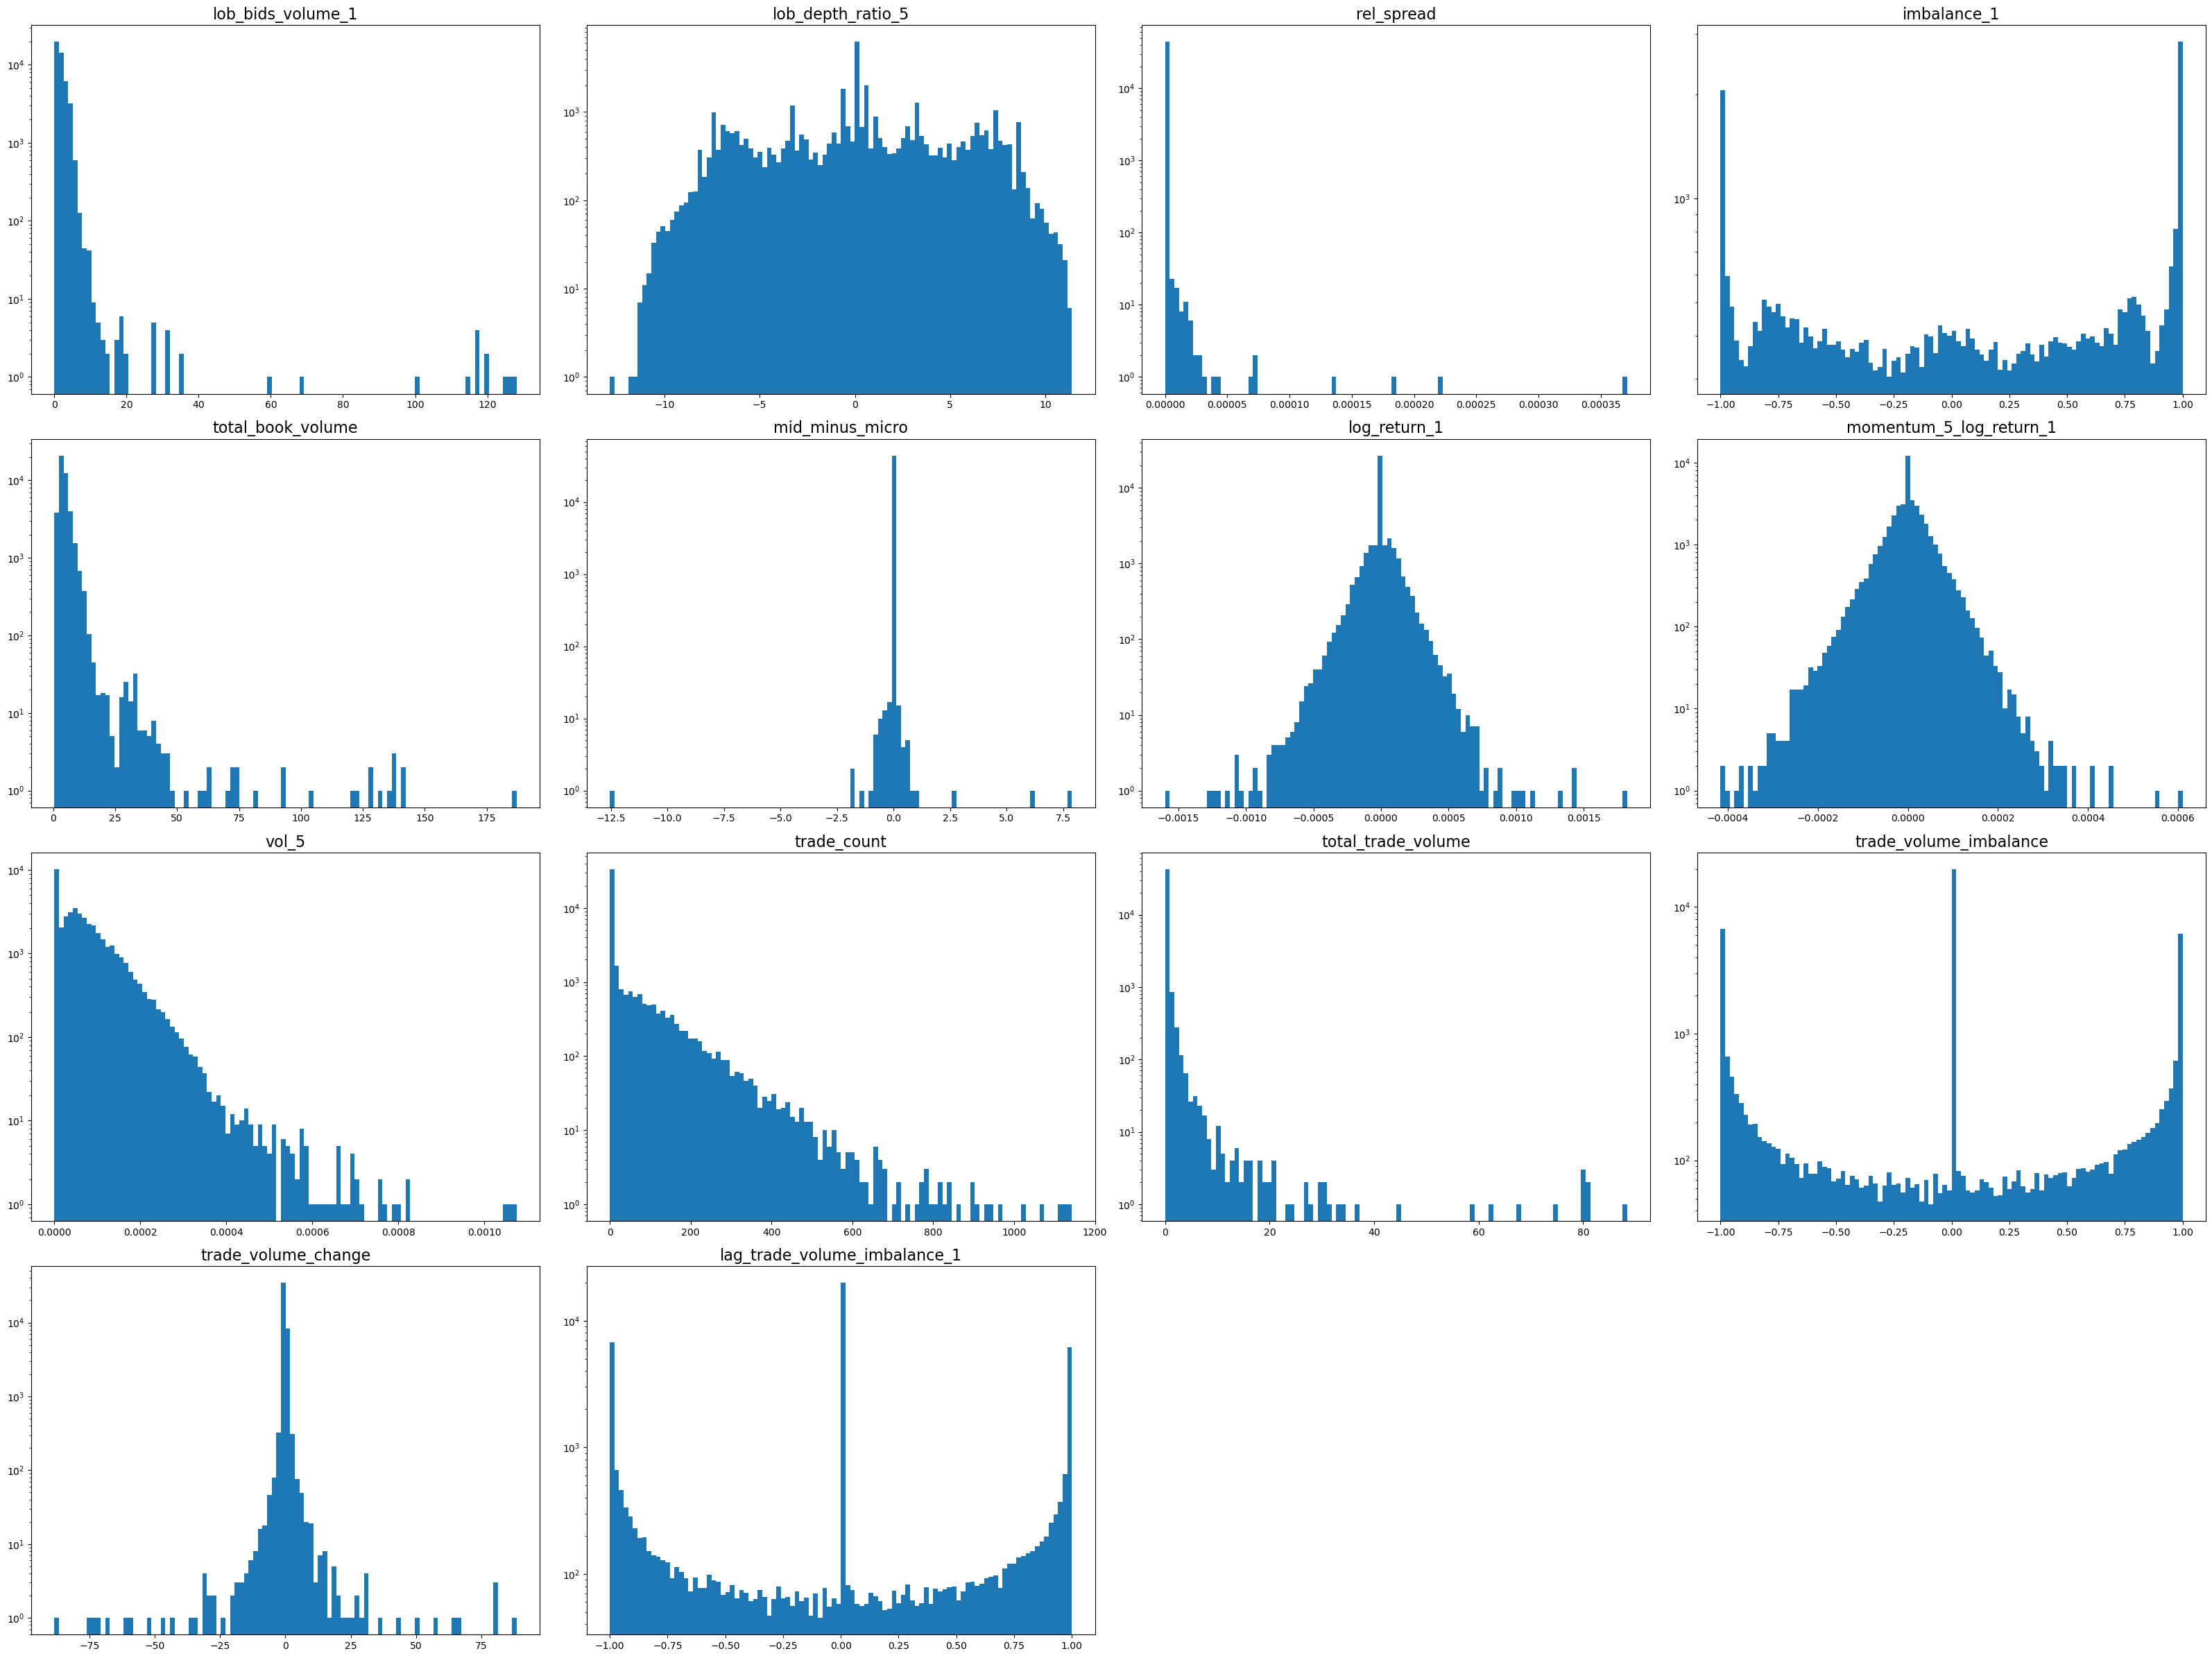

In [7]:
plot_check_features(final_dataset, check_features)

# Transformations
clip + standardise = cs (clip and standardising will be done in the training)
- lob_*_volume - log1p + cs
- lob_depth_Ratio - cs
- spreads - log1p + cs
- imbalances + trade imbalance - cs
- tot book vol - log1p + cs
- mid - micro - cs
- returns - cs
- vol feats - log1p + cs
- trade count total trade vol - logqp cs
- trade imbalance and lag maybe standardize
- trade volume change cs
## Remove raw vars
- remove bids prices, maybe instead normalize with mid_price?

In [8]:
def signed_log1p(x):
    x = x.astype(float).copy()
    x = np.sign(x) * np.log1p(np.abs(x))

    return x

In [ ]:
features_log1p = [
    "lob_bids_volume_1",
    "lob_bids_volume_2",
    "lob_bids_volume_3",
    "lob_bids_volume_4",
    "lob_bids_volume_5",
    "lob_bids_volume_6",
    "lob_bids_volume_7",
    "lob_bids_volume_8",
    "lob_bids_volume_9",
    "lob_bids_volume_10",
    "lob_asks_volume_1",
    "lob_asks_volume_2",
    "lob_asks_volume_3",
    "lob_asks_volume_4",
    "lob_asks_volume_5",
    "lob_asks_volume_6",
    "lob_asks_volume_7",
    "lob_asks_volume_8",
    "lob_asks_volume_9",
    "lob_asks_volume_10",
    "rel_spread",
    "spread",
    "liquidity",
    "total_bid_volume_10",
    "total_ask_volume_10",
    "total_book_volume",
    "max_bid_ask_vol_ratio",
    "mid_minus_micro",
    "vol_5",
    "vol_20",
    "realized_vol_5",
    "realized_vol_20",
    "trade_count",
    "buy_count",
    "sell_count",
    "total_trade_volume",
    "buy_volume",
    "sell_volume",
    "avg_trade_size",
    "max_trade_size",
    "min_trade_size",
    "std_trade_size",
    "max_over_average",
]

In [ ]:
for col in features_log1p:
    final_dataset[col + "_log1p"] = signed_log1p(final_dataset[col].values)

In [11]:
PATH = "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\processed\\final_dataset_40k_feature_transform.parquet"

final_dataset.to_parquet(
    PATH,
    compression="snappy",
)
final_dataset.head(25)

,timestamp,lob_bids_price_1,lob_bids_price_2,lob_bids_price_3,lob_bids_price_4,lob_bids_price_5,lob_bids_price_6,lob_bids_price_7,lob_bids_price_8,lob_bids_price_9,lob_bids_price_10,lob_bids_volume_1,lob_bids_volume_2,lob_bids_volume_3,lob_bids_volume_4,lob_bids_volume_5,lob_bids_volume_6,lob_bids_volume_7,lob_bids_volume_8,lob_bids_volume_9,lob_bids_volume_10,lob_asks_price_1,lob_asks_price_2,lob_asks_price_3,lob_asks_price_4,lob_asks_price_5,lob_asks_price_6,lob_asks_price_7,lob_asks_price_8,lob_asks_price_9,lob_asks_price_10,lob_asks_volume_1,lob_asks_volume_2,lob_asks_volume_3,lob_asks_volume_4,lob_asks_volume_5,lob_asks_volume_6,lob_asks_volume_7,lob_asks_volume_8,lob_asks_volume_9,lob_asks_volume_10,mid_price,spread,rel_spread,liquidity,total_bid_volume_10,total_ask_volume_10,total_book_volume,max_bid_ask_vol_ratio,imbalance_1,lob_depth_ratio_2,lob_depth_ratio_3,lob_depth_ratio_4,lob_depth_ratio_5,lob_depth_ratio_6,lob_depth_ratio_7,lob_depth_ratio_8,lob_depth_ratio_9,lob_depth_ratio_10,imbalance_5,imbalance_10,imbalance_depth_1,imbalance_depth_2,imbalance_depth_3,imbalance_depth_4,imbalance_depth_5,imbalance_depth_6,imbalance_depth_7,imbalance_depth_8,imbalance_depth_9,imbalance_depth_10,microprice,microprice_change,mid_minus_micro,microprice_weighted_10,return_1,return_5,log_return_1,log_return_2,log_return_3,log_return_5,log_return_20,momentum_5_log_return_1,momentum_20_log_return_1,vol_5,vol_20,realized_vol_5,realized_vol_20,mid_price_change_1,mid_price_change_1_sign,mid_price_change_5,mid_price_change_5_sign,mid_price_change_20,mid_price_change_20_sign,trade_count,buy_count,sell_count,total_trade_volume,buy_volume,sell_volume,avg_trade_size,max_trade_size,min_trade_size,std_trade_size,vwap,max_over_average,trade_volume_imbalance,trade_count_imbalance,trade_volume_change,trade_count_change,lag_trade_volume_imbalance_1,lag_trade_volume_imbalance_2,lag_trade_volume_imbalance_3,lag_trade_volume_imbalance_5,lob_bids_volume_1_log1p,lob_bids_volume_2_log1p,lob_bids_volume_3_log1p,lob_bids_volume_4_log1p,lob_bids_volume_5_log1p,lob_bids_volume_6_log1p,lob_bids_volume_7_log1p,lob_bids_volume_8_log1p,lob_bids_volume_9_log1p,lob_bids_volume_10_log1p,lob_asks_volume_1_log1p,lob_asks_volume_2_log1p,lob_asks_volume_3_log1p,lob_asks_volume_4_log1p,lob_asks_volume_5_log1p,lob_asks_volume_6_log1p,lob_asks_volume_7_log1p,lob_asks_volume_8_log1p,lob_asks_volume_9_log1p,lob_asks_volume_10_log1p,rel_spread_log1p,spread_log1p,liquidity_log1p,total_bid_volume_10_log1p,total_ask_volume_10_log1p,total_book_volume_log1p,max_bid_ask_vol_ratio_log1p,mid_minus_micro_log1p,vol_5_log1p,vol_20_log1p,realized_vol_5_log1p,realized_vol_20_log1p,trade_count_log1p,buy_count_log1p,sell_count_log1p,total_trade_volume_log1p,buy_volume_log1p,sell_volume_log1p,avg_trade_size_log1p,max_trade_size_log1p,min_trade_size_log1p,std_trade_size_log1p,max_over_average_log1p
0,1773138535267,70794.34,70794.33,70792.78,70792.77,70792.76,70792.21,70791.84,70791.15,70790.33,70790.32,1.13277,0.00032,0.00024,0.01925,0.04672,0.00008,0.00008,0.00200,0.00024,0.01080,70794.35,70794.36,70795.20,70795.34,70795.69,70795.99,70796.00,70796.10,70796.40,70796.46,2.19180,0.00024,0.00008,0.00300,0.00008,0.01518,0.04692,0.00159,0.00008,0.00200,70794.345,0.01,1.412542e-07,3.32457,1.21250,2.26097,3.47347,0.516822,-0.318546,0.287681,1.098604,1.858898,6.369889,-5.245695,-6.374160,0.229413,1.098604,1.686399,-0.293386,-0.301851,-0.318546,0.142857,0.499998,0.730337,0.996581,-0.989515,-0.996596,0.114206,0.499998,0.687500,70794.343386,0.000462,0.001614,70794.326451,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000243,0.000000,0.000012,0.000000,0.000048,0.000000,0.000214,0.00,0.0,0.00,0.0,-2.81,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.757422,0.00032,0.00024,0.019067,0.045661,0.000080,0.000080,0.001998,0.000240,0.010742,1.160585,0.000240,0.000080,0.002996,0.000080,0.015066,0.045853,0.001589,0.000080,0.001998,1.412542e-07,0.00995,1.464313,0.79